<a href="https://www.kaggle.com/code/mjawad17/global-meteorite-impacts-and-discoveries?scriptVersionId=302651198" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# <div style="text-align:center; border-radius:15px; padding:15px; color:white; margin:0; font-family: 'Orbitron', sans-serif; background: #2E0249; background: #11001C; box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.3); overflow:hidden; margin-bottom: 1em;"><h1 style="font-size:150%; color:#FEE100">Meteorite Landings Analysis Notebook</h1>

<!--</b><div style="text-align:left; ">This notebook performs an exploratory data analysis on the Meteorite Landings dataset to extract hidden patterns regarding meteorite impacts, discovery trends, and physical characteristics.</div></div>-->

In [1]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# kaggle default path script
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# Set plot style
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)


import warnings
# Ignore all warnings
warnings.filterwarnings('ignore')


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

/kaggle/input/datasets/sarcasmos/global-meteorite-impacts-and-discoveries/Meteorite_Landings.csv


## 1. Data Loading and Initial Inspection

In [2]:
# Load the dataset
df = pd.read_csv('/kaggle/input/datasets/sarcasmos/global-meteorite-impacts-and-discoveries/Meteorite_Landings.csv')

# Initial inspection
print("--- Data Info ---")
df.info()

print("\n--- Missing Values ---")
print(df.isnull().sum())

print("\n--- Duplicate Values ---")
print(df.duplicated().sum())

print("\n--- Unique Values ---")
for col in df.columns:
    unique_val = df[col].unique()
    print(f"Unique values in \033[1m{col}\033[0m': {unique_val}\n")

print("--- Top rows ---")
# displaying top 5 rows
df.head()

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45716 entries, 0 to 45715
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   name         45716 non-null  object 
 1   id           45716 non-null  int64  
 2   nametype     45716 non-null  object 
 3   recclass     45716 non-null  object 
 4   mass (g)     45585 non-null  float64
 5   fall         45716 non-null  object 
 6   year         45425 non-null  float64
 7   reclat       38401 non-null  float64
 8   reclong      38401 non-null  float64
 9   GeoLocation  38401 non-null  object 
dtypes: float64(4), int64(1), object(5)
memory usage: 3.5+ MB

--- Missing Values ---
name              0
id                0
nametype          0
recclass          0
mass (g)        131
fall              0
year            291
reclat         7315
reclong        7315
GeoLocation    7315
dtype: int64

--- Duplicate Values ---
0

--- Unique Values ---
Unique values in na

,name,id,nametype,recclass,mass (g),fall,year,reclat,reclong,GeoLocation
0,Aachen,1,Valid,L5,21.0,Fell,1880.0,50.77500,6.08333,"(50.775, 6.08333)"
1,Aarhus,2,Valid,H6,720.0,Fell,1951.0,56.18333,10.23333,"(56.18333, 10.23333)"
2,Abee,6,Valid,EH4,107000.0,Fell,1952.0,54.21667,-113.00000,"(54.21667, -113.0)"
3,Acapulco,10,Valid,Acapulcoite,1914.0,Fell,1976.0,16.88333,-99.90000,"(16.88333, -99.9)"
4,Achiras,370,Valid,L6,780.0,Fell,1902.0,-33.16667,-64.95000,"(-33.16667, -64.95)"


## 2. Data Cleaning

We need to handle missing values, filter out unrealistic years, and prepare the coordinates for mapping.

In [3]:
# Convert 'year' to datetime format. Since it's just a year number, we convert it to a datetime object representing the first day of that year.
df['year'] = pd.to_datetime(df['year'], format='%Y', errors='coerce')

# Clean coordinates for mapping (remove 0,0 and invalid longitudes)
df_clean_coords = df[(df['reclat'] != 0.0) | (df['reclong'] != 0.0)]
df_clean_coords = df_clean_coords.dropna(subset=['reclat', 'reclong'])
df_clean_coords = df_clean_coords[(df_clean_coords['reclong'] <= 180) & (df_clean_coords['reclong'] >= -180)]

print(f"Original records: {len(df)}")
print(f"Records with valid coordinates: {len(df_clean_coords)}")

Original records: 45716
Records with valid coordinates: 32186


## 3. Exploratory Data Analysis

### 3.1 Temporal Distribution
How have meteorite discoveries changed over time?

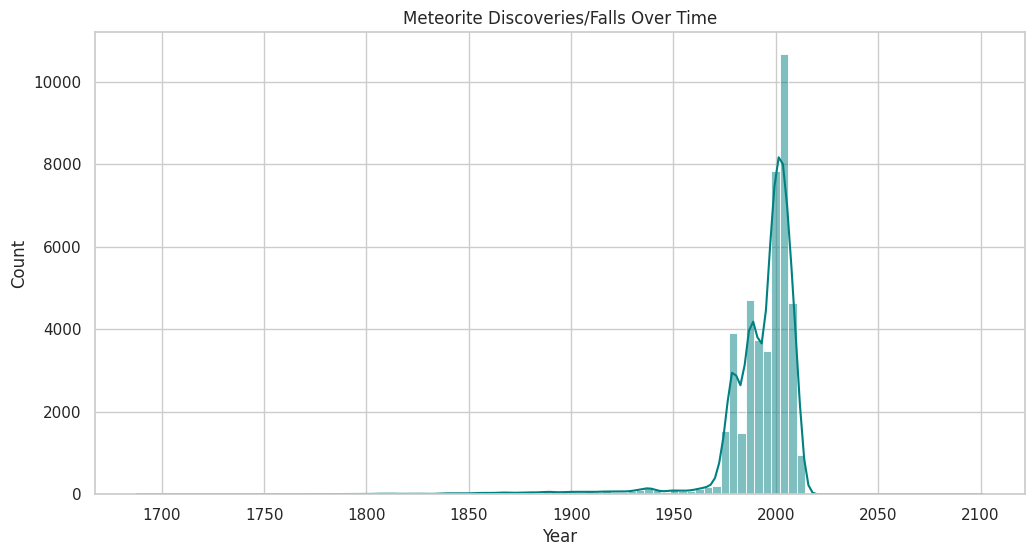

In [4]:
plt.figure(figsize=(12, 6))
sns.histplot(df['year'], bins=100, kde=True, color='teal')
plt.title('Meteorite Discoveries/Falls Over Time')
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()

### 3.2 Fall vs Found
Are most meteorites observed falling or found later?

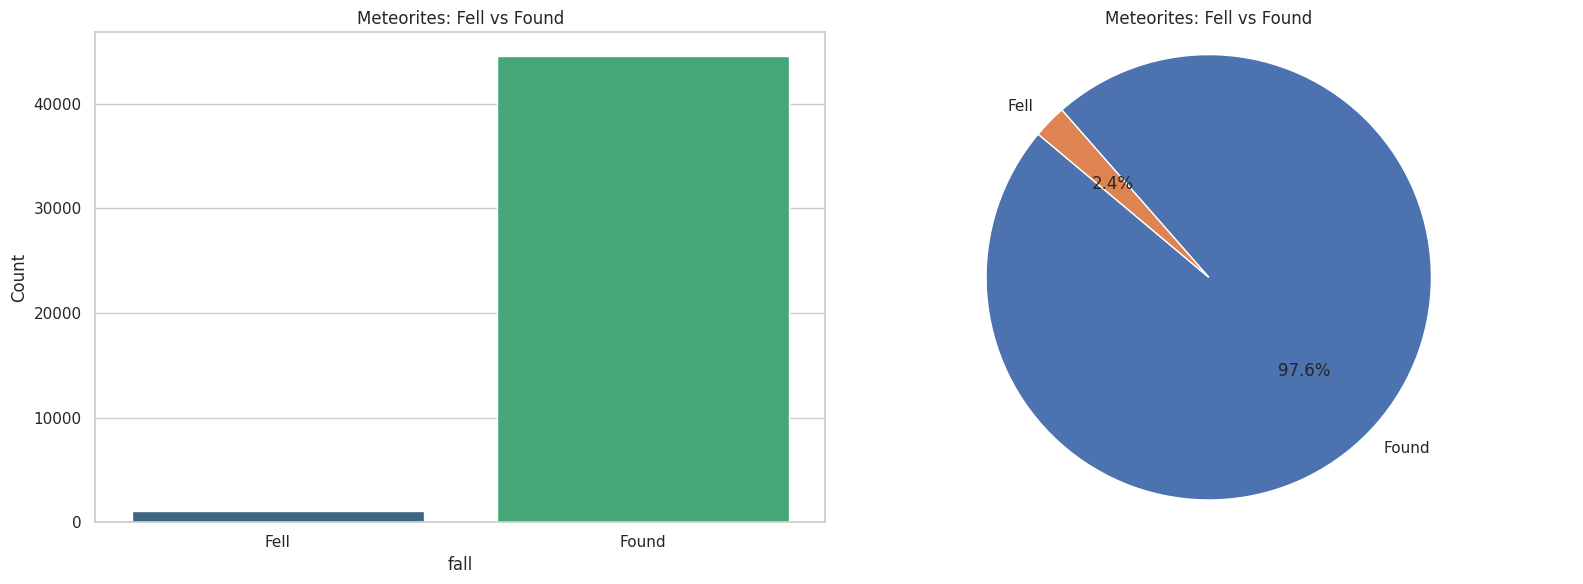

fall
Found    44609
Fell      1107
Name: count, dtype: int64


In [5]:
# Count the occurrences of each category
fall_counts = df['fall'].value_counts()

# Create a figure with two subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Count plot on the first subplot
sns.countplot(x='fall', data=df, palette='viridis', ax=axes[0])
axes[0].set_title('Meteorites: Fell vs Found')
axes[0].set_ylabel('Count')

# Pie chart on the second subplot
axes[1].pie(fall_counts, labels=fall_counts.index, autopct='%1.1f%%', startangle=140)
axes[1].set_title('Meteorites: Fell vs Found')
axes[1].axis('equal')

# Adjust layout
plt.tight_layout()
plt.show()

# Print the counts of each category
print(fall_counts)

### 3.3 Mass Distribution
Meteorite masses vary significantly, so we use a log scale.

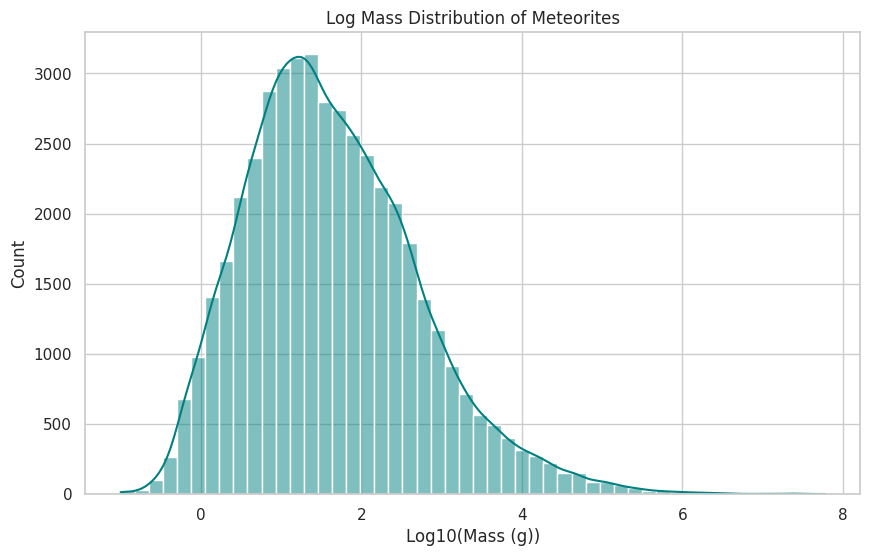

In [6]:
plt.figure(figsize=(10, 6))
sns.histplot(np.log10(df['mass (g)'] + 0.1), bins=50, kde=True, color='teal')
plt.title('Log Mass Distribution of Meteorites')
plt.xlabel('Log10(Mass (g))')
plt.ylabel('Count')
plt.show()

### 3.4 Top 10 Meteorite Classifications

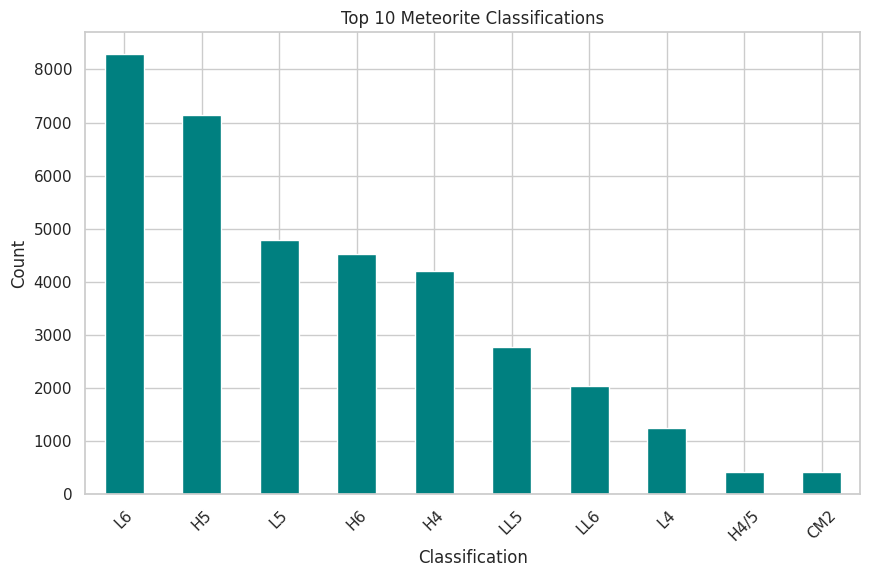

In [7]:
top_classes = df['recclass'].value_counts().head(10)
plt.figure(figsize=(10, 6))
top_classes.plot(kind='bar', color='teal')
plt.title('Top 10 Meteorite Classifications')
plt.xlabel('Classification')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

### 3.5 Global Distribution
Mapping where meteorites are found.

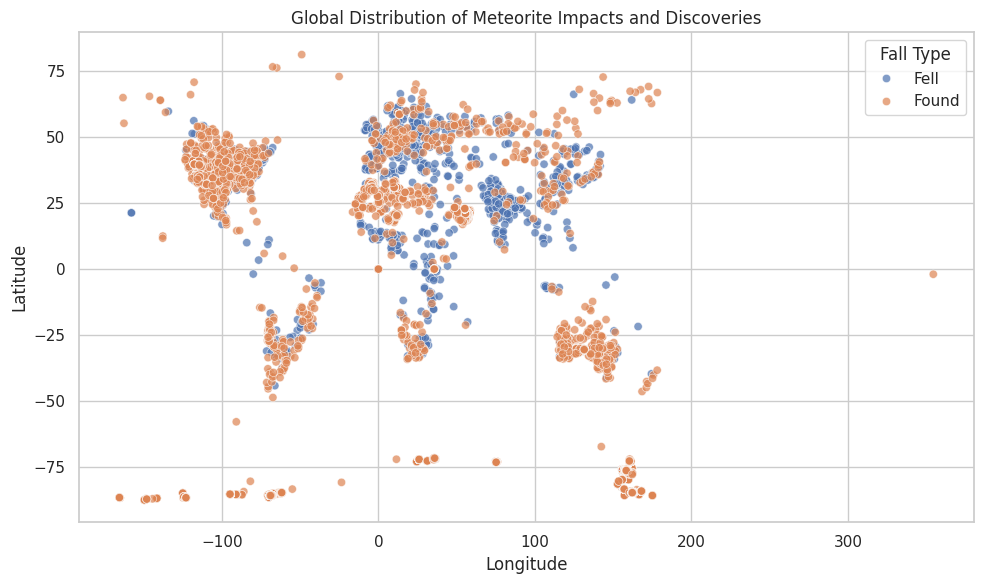

In [8]:
# Scatter plot for geolocation of meteorite landings
plt.figure(figsize=(10, 6))
sns.scatterplot(x='reclong', y='reclat', data=df, hue='fall', palette='deep', alpha=0.7)
plt.title('Global Distribution of Meteorite Impacts and Discoveries')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Fall Type')
plt.tight_layout()
plt.savefig('geolocation_scatter.png')
plt.show()

### 3.6 Mass vs. Discovery Year

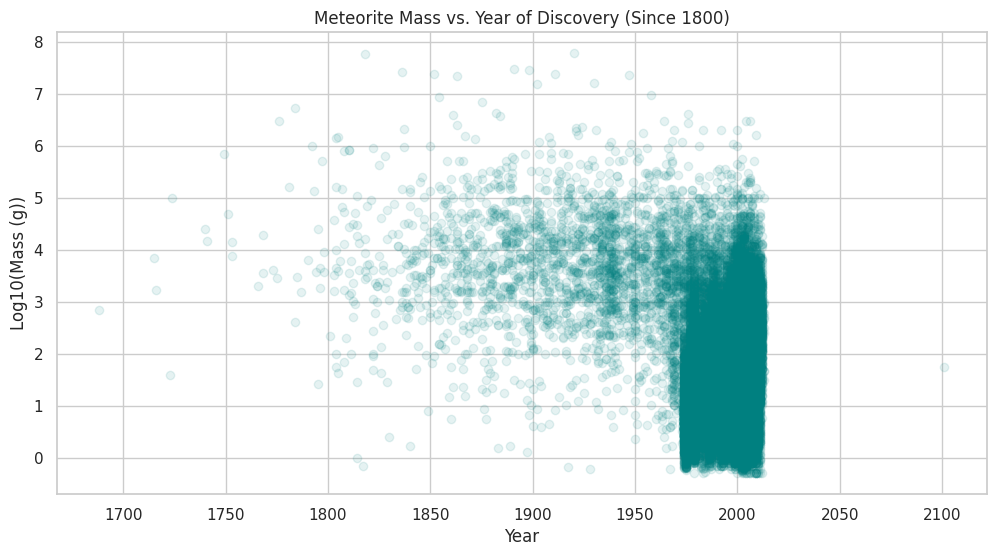

In [9]:
plt.figure(figsize=(12, 6))
plt.scatter(df['year'], np.log10(df['mass (g)']+0.5), alpha=0.1, color='teal')
plt.title('Meteorite Mass vs. Year of Discovery (Since 1800)')
plt.xlabel('Year')
plt.ylabel('Log10(Mass (g))')
plt.show()

### 3.7 Mass Distribution by Class

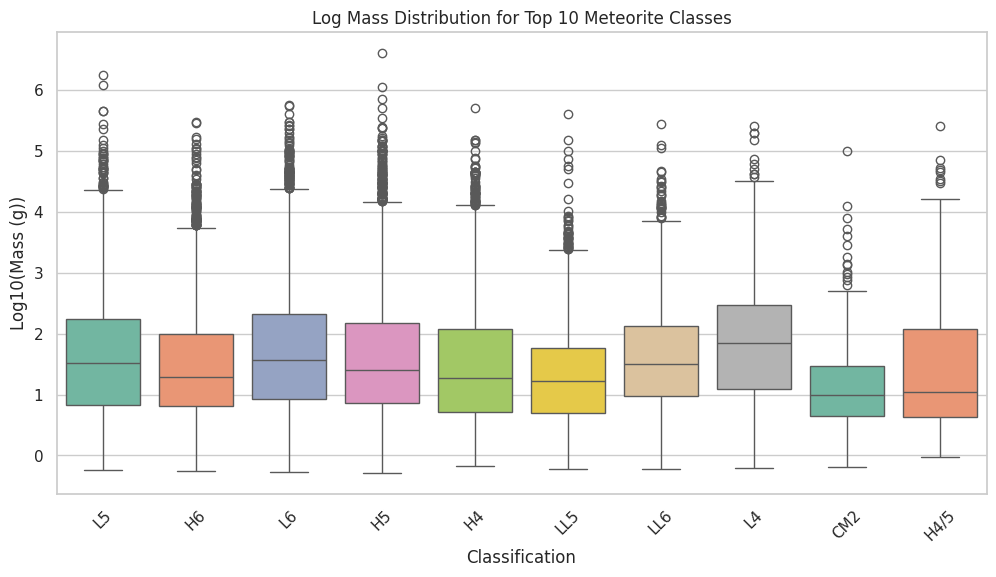

In [10]:
top_10_list = top_classes.index.tolist()
df_top_10 = df[df['recclass'].isin(top_10_list)]

plt.figure(figsize=(12, 6))
sns.boxplot(x='recclass', y=np.log10(df_top_10['mass (g)'] + 0.5), data=df_top_10, palette='Set2')
plt.title('Log Mass Distribution for Top 10 Meteorite Classes')
plt.xlabel('Classification')
plt.ylabel('Log10(Mass (g))')
plt.xticks(rotation=45)
plt.show()

The numeric features (id, mass, year as a number, reclat, reclong). We compute the correlation matrix and plot a heatmap if there are at least four numeric columns.

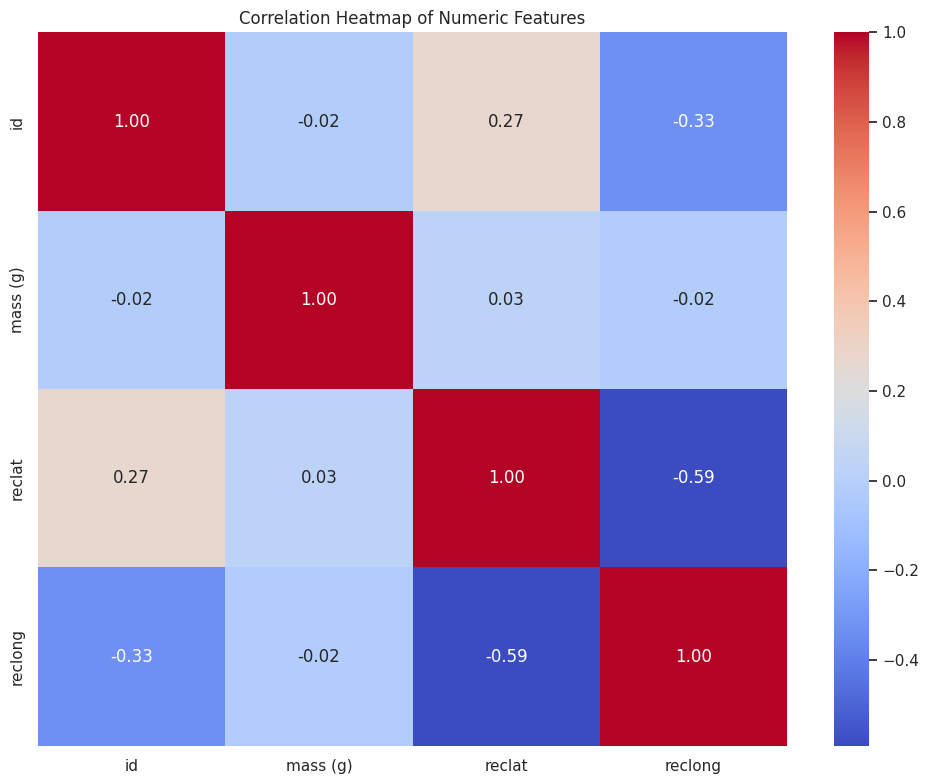

In [11]:
# Select numeric columns for correlation analysis
numeric_df = df.select_dtypes(include=[np.number])

if numeric_df.shape[1] >= 4:
    plt.figure(figsize=(10, 8))
    corr = numeric_df.corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Correlation Heatmap of Numeric Features')
    plt.tight_layout()
    plt.savefig('correlation_heatmap.png')
    plt.show()
else:
    print('Not enough numeric columns for correlation heatmap.')

## 4. Key Patterns and Conclusions

1. **Antarctic Concentration**: A significant portion of the discoveries are concentrated in Antarctica due to high visibility and ice movement.
2. **Discovery Growth**: Scientific expeditions post-1970 have led to a massive increase in meteorite records.
3. **Physical Profile**: Most meteorites are small stony types (L6, H5), while Iron meteorites are fewer but typically much larger in mass.
4. **Impact Data**: Only a small fraction of the dataset contains meteorites that were actually observed falling.

## 5. Prediction: Fall Type Classification

A simple logistic regression classifier to predict the 'fall' category (i.e. whether the meteorite was observed falling or was found) using available numeric features. For this purpose, I will use features such as mass, reclat, reclong, and year. Keep in mind that the prediction accuracy is only a rough indicator given the simplicity of the approach.

If you ever encounter issues with model convergence or imbalanced classes, consider applying appropriate scaling, regularization, or sampling methods.

In [12]:
# For prediction we need to encode the target variable 'fall'
df_pred = df.copy()

# Drop any rows with missing values in the features used for prediction
df_pred = df_pred.dropna(subset=['mass (g)', 'reclat', 'reclong', 'year'])

In [13]:
# Feature Engineering: Convert 'year' to numeric year for model consumption
df_pred['year_numeric'] = df_pred['year'].dt.year

# Select features
features = ['mass (g)', 'reclat', 'reclong', 'year_numeric']

# Encode target variable: Let's assume 'Fell' as 1 and 'Found' as 0
df_pred['fall_encoded'] = df_pred['fall'].apply(lambda x: 1 if x.lower() == 'fell' else 0)

In [14]:
X = df_pred[features]
y = df_pred['fall_encoded']

# Split the dataset into training and testing subsets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Initialize and train the logistic regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Calculate and print the accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy of the Logistic Regression classifier: {accuracy:.2f}')

Accuracy of the Logistic Regression classifier: 0.97


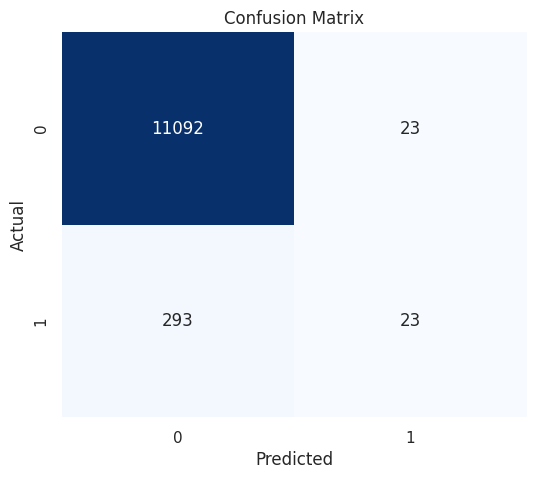

In [15]:
# Plot the confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

---
# Thank You!
Thank you for taking the time to view my notebook. I truly appreciate your interest and support!

💬 I'm always open to feedback or suggestions for improving the analysis — feel free to share your thoughts!

👍 If you found this helpful or insightful, a vote would mean a lot and help keep me motivated to keep learning and sharing more work.

Thanks again and happy coding! 😊